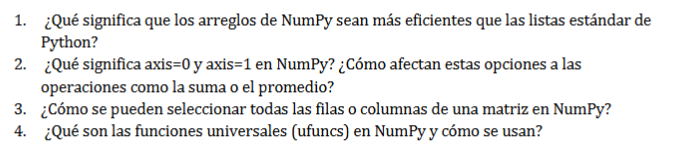

1. porqu numpy tiene metodos personalizados, para trabajar con arreglos numericos, con las listas normales uno mismo debe crear lo metodos, lo que es menos eficiente
2. Significa como operar axis=0 significa operar por columnas y axis=1 significa operar por filas.
3. con el parametro axis=0,1
4. funciones o metoods que permite operar en cada elemendo de un arreglo

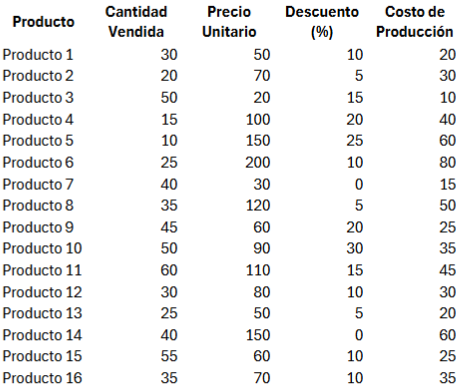
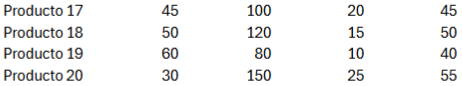

In [1]:
import numpy as np
import pandas as pd

# Nombres de productos
productos = np.array([
    "Producto 1", "Producto 2", "Producto 3", "Producto 4",
    "Producto 5", "Producto 6", "Producto 7", "Producto 8",
    "Producto 9", "Producto 10", "Producto 11", "Producto 12",
    "Producto 13", "Producto 14", "Producto 15", "Producto 16"
])

# Datos numéricos: Cantidad Vendida, Precio Unitario, Descuento (%), Costo de Producción
datos = np.array([
    [30, 50, 10, 20],
    [20, 70, 5, 30],
    [50, 20, 15, 10],
    [15, 100, 20, 40],
    [10, 150, 25, 60],
    [25, 200, 0, 80],
    [40, 30, 0, 15],
    [35, 120, 5, 50],
    [45, 60, 20, 25],
    [50, 90, 30, 35],
    [60, 110, 15, 45],
    [30, 80, 10, 30],
    [25, 50, 5, 12],
    [40, 150, 0, 60],
    [50, 60, 10, 25],
    [35, 70, 10, 35]
])

df = pd.DataFrame(datos, columns=["Cantidad Vendida", "Precio Unitario", "Descuento (%)", "Costo de Producción"])
df.insert(0, "Producto", productos)
print(df)

       Producto  Cantidad Vendida  Precio Unitario  Descuento (%)  \
0    Producto 1                30               50             10   
1    Producto 2                20               70              5   
2    Producto 3                50               20             15   
3    Producto 4                15              100             20   
4    Producto 5                10              150             25   
5    Producto 6                25              200              0   
6    Producto 7                40               30              0   
7    Producto 8                35              120              5   
8    Producto 9                45               60             20   
9   Producto 10                50               90             30   
10  Producto 11                60              110             15   
11  Producto 12                30               80             10   
12  Producto 13                25               50              5   
13  Producto 14                40 

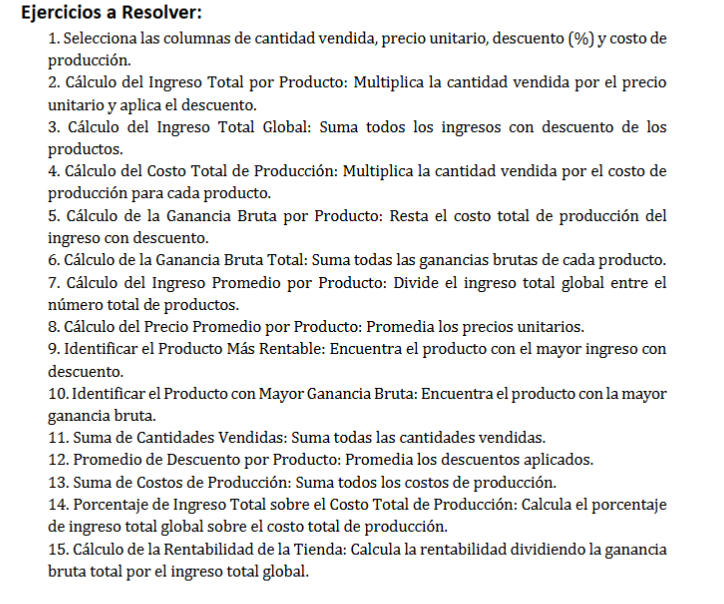

In [3]:
## 1. seleccionar columnas
print(df)

       Producto  Cantidad Vendida  Precio Unitario  Descuento (%)  \
0    Producto 1                30               50             10   
1    Producto 2                20               70              5   
2    Producto 3                50               20             15   
3    Producto 4                15              100             20   
4    Producto 5                10              150             25   
5    Producto 6                25              200              0   
6    Producto 7                40               30              0   
7    Producto 8                35              120              5   
8    Producto 9                45               60             20   
9   Producto 10                50               90             30   
10  Producto 11                60              110             15   
11  Producto 12                30               80             10   
12  Producto 13                25               50              5   
13  Producto 14                40 

In [14]:
# 2. Ingreso Total de producto
##conversion tipos
df[["Precio Unitario", "Descuento (%)", "Costo de Producción"]]=df[
    ["Precio Unitario", "Descuento (%)", "Costo de Producción"]
].astype(float)

df_copia=df
print(df_copia.info())

def calcular_ingreso(cantidad, precio,descuento):
    return cantidad * (precio*((100-descuento)/100))


df_copia["IngresoxProducto"]=calcular_ingreso(df_copia["Cantidad Vendida"],df_copia["Precio Unitario"],df_copia["Descuento (%)"])
print("\n")
print(df_copia["IngresoxProducto"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Producto             16 non-null     object 
 1   Cantidad Vendida     16 non-null     int64  
 2   Precio Unitario      16 non-null     float64
 3   Descuento (%)        16 non-null     float64
 4   Costo de Producción  16 non-null     float64
 5   IngresoxProducto     16 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 900.0+ bytes
None


0     1350.0
1     1330.0
2      850.0
3     1200.0
4     1125.0
5     5000.0
6     1200.0
7     3990.0
8     2160.0
9     3150.0
10    5610.0
11    2160.0
12    1187.5
13    6000.0
14    2700.0
15    2205.0
Name: IngresoxProducto, dtype: float64


In [15]:
# 3. # Suma total de la columna IngresoxProducto
total_ingresos = df_copia["IngresoxProducto"].sum()

print("Ingreso total de todos los productos:", total_ingresos)


Ingreso total de todos los productos: 41217.5


In [19]:
# 4. Costo total de Produccion
# print(df_copia)

def costo_total_xProducto(cantidad, costo):
    return cantidad * costo


df_copia["costoxProducto"]=costo_total_xProducto(df_copia["Cantidad Vendida"],df_copia["Costo de Producción"])

total_costos=df_copia["costoxProducto"].sum()

print("Costo total de todos los productos: ",total_costos )

Costo total de todos los productos:  18900.0


In [23]:
#5. Ganancia bruta por producto

print(df_copia.info())

def ganancia_bruta(ganancia_total, costo_total):
    return ganancia_total-costo_total

df_copia["ganancia_bruta"]=ganancia_bruta(df_copia["IngresoxProducto"],df_copia["costoxProducto"])

print(df_copia.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Producto             16 non-null     object 
 1   Cantidad Vendida     16 non-null     int64  
 2   Precio Unitario      16 non-null     float64
 3   Descuento (%)        16 non-null     float64
 4   Costo de Producción  16 non-null     float64
 5   IngresoxProducto     16 non-null     float64
 6   costoxProducto       16 non-null     float64
 7   ganancia_bruta       16 non-null     float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ KB
None
     Producto  Cantidad Vendida  Precio Unitario  Descuento (%)  \
0  Producto 1                30             50.0           10.0   
1  Producto 2                20             70.0            5.0   
2  Producto 3                50             20.0           15.0   
3  Producto 4                15            100.0           20.0

In [24]:
# 6. Ganancia bruta total 
ganancia_bruta_total=df_copia["ganancia_bruta"].sum()
print("Ganancia Bruta Total: ",ganancia_bruta_total)



Ganancia Bruta Total:  22317.5


In [26]:
# 7. ingreso total por productos

nume_productos=df_copia["Cantidad Vendida"].sum()

gananciaXproducto=ganancia_bruta_total/nume_productos

print("gnancia bruta por producto promedio: ",gananciaXproducto)

gnancia bruta por producto promedio:  39.85267857142857


In [27]:
# 8. promedio de precios por producto

precio_promedioProductos=df_copia["Precio Unitario"].mean()

print("Precio Promedio por producto: ",precio_promedioProductos)

Precio Promedio por producto:  88.125


In [32]:
# 9. promedio del producto mas rentable
print(df_copia["IngresoxProducto"].describe())

max_valor = df_copia["IngresoxProducto"].max()
print("Máxima ganancia no bruta, sin descontar costo:", max_valor)

registro_max = df_copia.loc[df_copia["IngresoxProducto"].idxmax()]
print(registro_max)




count      16.000000
mean     2576.093750
std      1702.693202
min       850.000000
25%      1200.000000
50%      2160.000000
75%      3360.000000
max      6000.000000
Name: IngresoxProducto, dtype: float64
Máxima ganancia no bruta, sin descontar costo: 6000.0
Producto               Producto 14
Cantidad Vendida                40
Precio Unitario              150.0
Descuento (%)                  0.0
Costo de Producción           60.0
IngresoxProducto            6000.0
costoxProducto              2400.0
ganancia_bruta              3600.0
Name: 13, dtype: object


In [31]:
# 10. promedio del producto mas rentable
print(df_copia["ganancia_bruta"].describe())

max_valor = df_copia["ganancia_bruta"].max()
print("Máxima ganancia bruta:", max_valor)

registro_max = df_copia.loc[df_copia["ganancia_bruta"].idxmax()]
print(registro_max)


count      16.000000
mean     1394.843750
std       999.972695
min       350.000000
25%       697.500000
50%      1007.500000
75%      1647.500000
max      3600.000000
Name: ganancia_bruta, dtype: float64
Máxima ganancia bruta: 3600.0
Producto               Producto 14
Cantidad Vendida                40
Precio Unitario              150.0
Descuento (%)                  0.0
Costo de Producción           60.0
IngresoxProducto            6000.0
costoxProducto              2400.0
ganancia_bruta              3600.0
Name: 13, dtype: object


In [34]:
# 12  promedio de los descuentso aplicados

def descuento_aplicado(precio,descuento):
    return precio*((100-descuento)/100)

df_copia["descuento_producto"]=descuento_aplicado(df_copia["Precio Unitario"],df_copia["Descuento (%)"])

descuento_promedio=df_copia["descuento_producto"].mean()

print("Descuento promedio aplicado por producto: ",descuento_promedio)


Descuento promedio aplicado por producto:  78.5


In [39]:
# 13 suma costos de produccion

print(df_copia.head(2))

costo_produccion_promedio=df_copia["Costo de Producción"].mean()
print("costo de produccion Promedio: ",costo_produccion_promedio)

     Producto  Cantidad Vendida  Precio Unitario  Descuento (%)  \
0  Producto 1                30             50.0           10.0   
1  Producto 2                20             70.0            5.0   

   Costo de Producción  IngresoxProducto  costoxProducto  ganancia_bruta  \
0                 20.0            1350.0           600.0           750.0   
1                 30.0            1330.0           600.0           730.0   

   descuento_producto  
0                45.0  
1                66.5  
costo de produccion Promedio:  35.75


In [52]:
# 14. porcentaje de ingreso en relacion al costo de produccion

porcentaje_gananciaXcosto=(((total_ingresos-total_costos)/total_costos))*100

print("porcentaje ganacia total por costo: ",porcentaje_gananciaXcosto)
print(f"se concluye que es rentable, se obtubo como ganancia el {round(porcentaje_gananciaXcosto,2)}% del costo de produccion adicional")

porcentaje ganacia total por costo:  118.08201058201058
se concluye que es rentable, se obtubo como ganancia el 118.08% del costo de produccion adicional


In [ ]:
# 15
porcetaje_rentabilidad_total=(ganancia_bruta_total/total_ingresos)*100

print(f"se obtuvo una ganancia del {round(porcetaje_rentabilidad_total,2)} %")

se obtuvo una ganancia del 54.15
